In [1]:
# /// script
# requires-python = ">=3.12"
# dependencies = [
#     "matplotlib",
#     "numpy",
#     "pandas",
#     "polars",
#     "pyarrow",
#     "seaborn",
# ]
#
# [tool.uv]
# exclude-newer = "2025-09-03T15:32:35.941220375+02:00"
# ///

In [2]:
import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

In [3]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

In [4]:
data_path = Path("/mnt/e25c8328-9cc4-46c3-847f-08c52bbdb6b8/CNS2022_CICIDS2017_improved")

In [5]:
df = pl.concat([
    pl.read_csv(f"{data_path}/monday.csv"),
    pl.read_csv(f"{data_path}/tuesday.csv"),
    pl.read_csv(f"{data_path}/wednesday.csv"),
    pl.read_csv(f"{data_path}/thursday.csv"),
    pl.read_csv(f"{data_path}/friday.csv"),
])
df = df.with_columns(
    pl.col("Timestamp").str.strptime(pl.Datetime, "%Y-%m-%d %H:%M:%S%.f").dt.date().alias("date")
)
df.head()

id,Flow ID,Src IP,Src Port,Dst IP,Dst Port,Protocol,Timestamp,Flow Duration,Total Fwd Packet,Total Bwd packets,Total Length of Fwd Packet,Total Length of Bwd Packet,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,Bwd Packet Length Min,Bwd Packet Length Mean,Bwd Packet Length Std,Flow Bytes/s,Flow Packets/s,Flow IAT Mean,Flow IAT Std,Flow IAT Max,Flow IAT Min,Fwd IAT Total,Fwd IAT Mean,Fwd IAT Std,Fwd IAT Max,Fwd IAT Min,Bwd IAT Total,Bwd IAT Mean,Bwd IAT Std,Bwd IAT Max,Bwd IAT Min,…,PSH Flag Count,ACK Flag Count,URG Flag Count,CWR Flag Count,ECE Flag Count,Down/Up Ratio,Average Packet Size,Fwd Segment Size Avg,Bwd Segment Size Avg,Fwd Bytes/Bulk Avg,Fwd Packet/Bulk Avg,Fwd Bulk Rate Avg,Bwd Bytes/Bulk Avg,Bwd Packet/Bulk Avg,Bwd Bulk Rate Avg,Subflow Fwd Packets,Subflow Fwd Bytes,Subflow Bwd Packets,Subflow Bwd Bytes,FWD Init Win Bytes,Bwd Init Win Bytes,Fwd Act Data Pkts,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,ICMP Code,ICMP Type,Total TCP Flow Time,Label,Attempted Category,date
i64,str,str,i64,str,i64,i64,str,i64,i64,i64,i64,i64,i64,i64,f64,f64,i64,i64,f64,f64,f64,f64,f64,f64,i64,i64,i64,f64,f64,i64,i64,i64,f64,f64,i64,i64,…,i64,i64,i64,i64,i64,f64,f64,f64,f64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,f64,f64,i64,i64,f64,f64,i64,i64,i64,i64,i64,str,i64,date
1,"""8.6.0.1-8.0.6.4-0-0-0""","""8.6.0.1""",0,"""8.0.6.4""",0,0,"""2017-07-03 11:56:34.157427""",119719148,231,0,0,0,0,0,0.0,0.0,0,0,0.0,0.0,0.0,1.929516,520518.034783,2.2745e6,20694308,0,119719148,520518.034783,2.2745e6,20694308,0,0,0.0,0.0,0,0,…,0,0,0,0,0,0.0,0.0,0.0,0.0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,8721243.6,8.7618e6,22509459,17,1.2685486e7,5.2967e6,20694308,6499982,-1,-1,0,"""BENIGN""",-1,2017-07-03
2,"""192.168.10.9-192.168.10.3-123-…","""192.168.10.9""",123,"""192.168.10.3""",123,17,"""2017-07-03 11:56:55.428911""",65511209,6,6,288,288,48,48,48.0,0.0,48,48,48.0,0.0,8.792388,0.183175,5.9556e6,1.9258e7,64004884,3,65511097,1.3102e7,2.8463e7,64004961,3,65511105,1.3102221e7,2.8463e7,64004995,3,…,0,0,0,0,0,1.0,48.0,48.0,48.0,0,0,0,0,0,0,0,24,0,24,0,0,5,8,1.50621e6,0.0,1506210,1506210,6.4004884e7,0.0,64004884,64004884,-1,-1,0,"""BENIGN""",-1,2017-07-03
3,"""192.168.10.12-224.0.0.251-5353…","""192.168.10.12""",5353,"""224.0.0.251""",5353,17,"""2017-07-03 11:57:21.057686""",113976922,267,0,20447,0,153,37,76.580524,44.140625,0,0,0.0,0.0,179.395966,2.342579,428484.669173,3.7018e6,48523116,0,113976922,428484.669173,3.7018e6,48523116,0,0,0.0,0.0,0,0,…,0,0,0,0,0,0.0,76.580524,76.580524,0.0,2044,26,4794,0,0,0,1,76,0,0,0,0,266,8,2745981.5,5.4919e6,10983883,14,2.5498178e7,1.8833e7,48523116,5463561,-1,-1,0,"""BENIGN""",-1,2017-07-03
4,"""192.168.10.12-152.2.133.52-123…","""192.168.10.12""",123,"""152.2.133.52""",123,17,"""2017-07-03 11:57:31.568196""",67037196,8,8,384,384,48,48,48.0,0.0,48,48,48.0,0.0,11.456326,0.238673,4469146.4,1.4272e7,55956316,44916,66990997,9.5701e6,2.0478e7,56001261,992873,66991090,9.5702e6,2.0478e7,56002515,991683,…,0,0,0,0,0,1.0,48.0,48.0,48.0,0,0,0,0,0,0,0,24,0,24,0,0,7,8,1.1034681e7,0.0,11034681,11034681,5.5956316e7,0.0,55956316,55956316,-1,-1,0,"""BENIGN""",-1,2017-07-03
5,"""192.168.10.12-45.79.11.217-123…","""192.168.10.12""",123,"""45.79.11.217""",123,17,"""2017-07-03 11:57:30.571719""",68045057,8,8,384,384,48,48,48.0,0.0,48,48,48.0,0.0,11.286639,0.235138,4.5363e6,1.4525e7,56943904,57451,67987500,9.7125e6,2.0856e7,57001355,989295,67987529,9.7125e6,2.0856e7,57001461,989348,…,0,0,0,0,0,1.0,48.0,48.0,48.0,0,0,0,0,0,0,0,24,0,24,0,0,7,8,1.1043596e7,0.0,11043596,11043596,5.6943904e7,0.0,56943904,56943904,-1,-1,0,"""BENIGN""",-1,2017-07-03


In [6]:
print(f"Loaded {df.shape[0]:,} rows with {df.estimated_size() / (1024**2):,.1f} MB in memory.")

Loaded 2,099,976 rows with 1,575.6 MB in memory.


In [7]:
FEATURES = [
    "Protocol",
    "ICMP Code",
    "ICMP Type",
    "Flow Duration",
    "Total Fwd Packet",
    "Total Bwd packets",
    "Total Length of Fwd Packet",
    "Total Length of Bwd Packet",
    "Fwd Packet Length Max",
    "Fwd Packet Length Min",
    "Fwd Packet Length Mean",
    "Fwd Packet Length Std",
    "Bwd Packet Length Max",
    "Bwd Packet Length Min",
    "Bwd Packet Length Mean",
    "Bwd Packet Length Std",
    "Flow Bytes/s",
    "Flow Packets/s",
    "Flow IAT Mean",
    "Flow IAT Std",
    "Flow IAT Max",
    "Flow IAT Min",
    "Fwd IAT Total",
    "Fwd IAT Mean",
    "Fwd IAT Std",
    "Fwd IAT Max",
    "Fwd IAT Min",
    "Bwd IAT Total",
    "Bwd IAT Mean",
    "Bwd IAT Std",
    "Bwd IAT Max",
    "Bwd IAT Min",
    "Fwd PSH Flags",
    "Bwd PSH Flags",
    "Fwd URG Flags",
    "Bwd URG Flags",
    "Fwd RST Flags",
    "Bwd RST Flags",
    "Fwd Header Length",
    "Bwd Header Length",
    "Fwd Packets/s",
    "Bwd Packets/s",
    "Packet Length Min",
    "Packet Length Max",
    "Packet Length Mean",
    "Packet Length Std",
    "Packet Length Variance",
    "FIN Flag Count",
    "SYN Flag Count",
    "RST Flag Count",
    "PSH Flag Count",
    "ACK Flag Count",
    "URG Flag Count",
    "CWR Flag Count",
    "ECE Flag Count",
    "Down/Up Ratio",
    "Average Packet Size",
    "Fwd Segment Size Avg",
    "Bwd Segment Size Avg",
    "Fwd Bytes/Bulk Avg",
    "Fwd Packet/Bulk Avg",
    "Fwd Bulk Rate Avg",
    "Bwd Bytes/Bulk Avg",
    "Bwd Packet/Bulk Avg",
    "Bwd Bulk Rate Avg",
    "Subflow Fwd Packets",
    "Subflow Fwd Bytes",
    "Subflow Bwd Packets",
    "Subflow Bwd Bytes",
    "FWD Init Win Bytes",
    "Bwd Init Win Bytes",
    "Fwd Act Data Pkts",
    "Bwd Act Data Pkts",
    "Fwd Seg Size Min",
    "Bwd Seg Size Min",
    "Active Mean",
    "Active Std",
    "Active Max",
    "Active Min",
    "Idle Mean",
    "Idle Std",
    "Idle Max",
    "Idle Min",
    "Fwd TCP Retrans. Count",
    "Bwd TCP Retrans. Count",
    "Total TCP Retrans. Count",
    "Total Connection Flow Time",
]

for feature in FEATURES:
    if feature not in df.columns:
        print(f"Feature '{feature}' not found in DataFrame columns.")

Feature 'Bwd Act Data Pkts' not found in DataFrame columns.
Feature 'Bwd Seg Size Min' not found in DataFrame columns.
Feature 'Fwd TCP Retrans. Count' not found in DataFrame columns.
Feature 'Bwd TCP Retrans. Count' not found in DataFrame columns.
Feature 'Total TCP Retrans. Count' not found in DataFrame columns.
Feature 'Total Connection Flow Time' not found in DataFrame columns.


In [8]:
# all containing attempted labels are changed to BENIGN
df = df.with_columns(
    pl.when(pl.col("Label").str.to_lowercase().str.contains("attempted"))
      .then(pl.lit("BENIGN"))
      .otherwise(pl.col("Label"))
      .alias("Label")
)

In [9]:
taxonomy_counts = df['Label'].value_counts()\
    .sort(by='count', descending=True)\
    .to_pandas()
taxonomy_counts

,Label,count
0,BENIGN,1594545
1,Portscan,159066
2,DoS Hulk,158468
3,DDoS,95144
4,Infiltration - Portscan,71767
5,DoS GoldenEye,7567
6,FTP-Patator,3972
7,DoS Slowloris,3859
8,SSH-Patator,2961
9,DoS Slowhttptest,1740


In [10]:
(
    taxonomy_counts.assign(Label=np.where(taxonomy_counts["Label"].eq("BENIGN"), "BENIGN", "NON_BENIGN"))
      .groupby("Label", as_index=False, sort=False)["count"]
      .sum()
      .sort_values(by="Label", key=lambda s: s.ne("BENIGN"))  # BENIGN first
      .reset_index(drop=True)
)

,Label,count
0,BENIGN,1594545
1,NON_BENIGN,505431


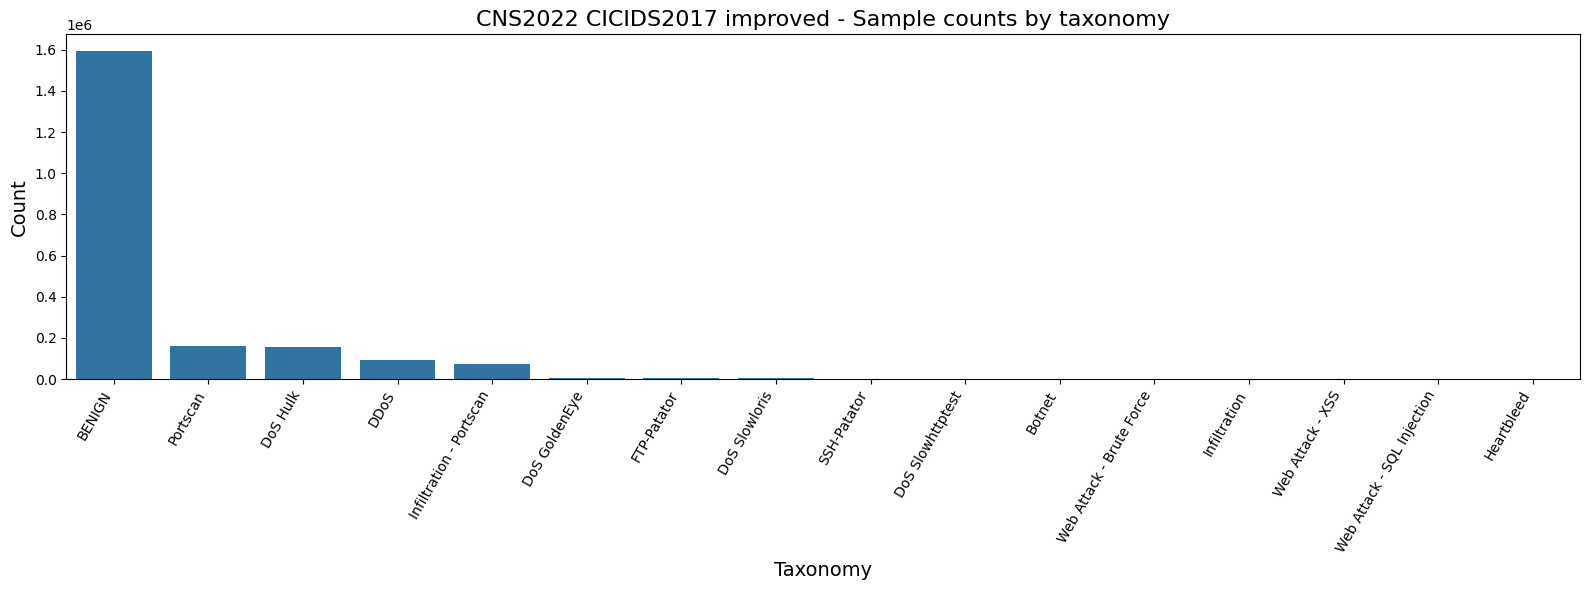

In [11]:
plt.figure(figsize=(16, 6))
sns.barplot(data=taxonomy_counts, x='Label', y='count')

plt.xticks(rotation=60, ha='right', fontsize=10)
plt.title('CNS2022 CICIDS2017 improved - Sample counts by taxonomy', fontsize=16)
plt.xlabel('Taxonomy', fontsize=14)
plt.ylabel('Count', fontsize=14)
plt.tight_layout()
plt.show()

In [12]:
taxonomy_daily = (
    df
    .group_by(['date', 'Label'])
    .agg(pl.len())
    .with_columns([
        pl.col('len').alias('count')
    ])
    .select(['date', 'Label', 'count'])
    .sort(['date', 'Label'])
    .to_pandas()
    .pivot(index='date', columns='Label', values='count')
)

In [13]:
label_daily = (
    taxonomy_daily.fillna(0)
    .assign(NON_BENIGN=lambda d: d.drop(columns=["BENIGN"], errors="ignore").sum(axis=1))
    .reindex(columns=["BENIGN", "NON_BENIGN"])
    .fillna(0)
    .astype("Int64")
)

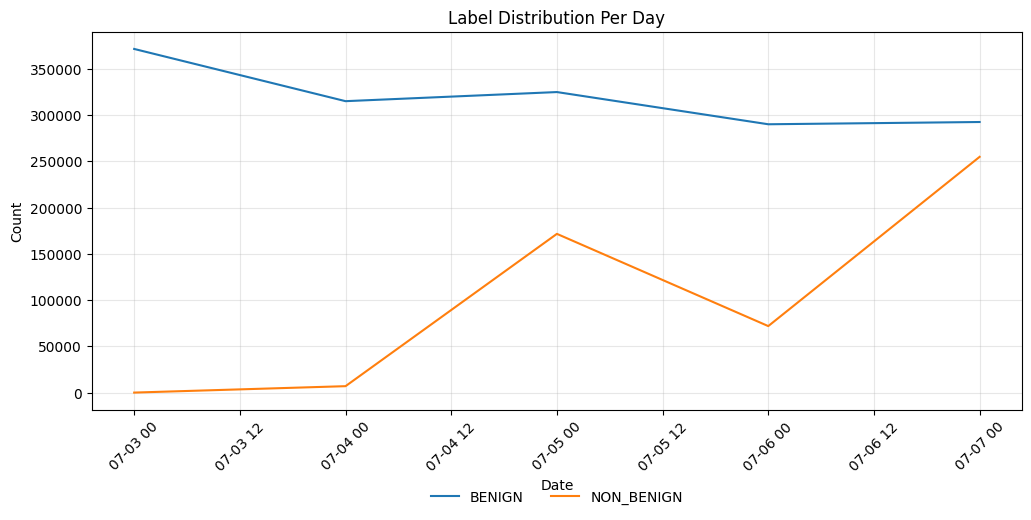

In [14]:
plt.figure(figsize=(12, 6))
for column in label_daily.columns:
    sns.lineplot(
        x=label_daily.index,
        y=label_daily[column],
        label=column
    )

plt.title("Label Distribution Per Day")
plt.xlabel("Date")
plt.ylabel("Count")
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.legend(
    loc='upper center',
    bbox_to_anchor=(0.5, -0.18),  # center, below the axes
    ncol=3,                       # spread items across columns
    frameon=False
)
plt.subplots_adjust(bottom=0.25)  # make room for the legend
plt.show()

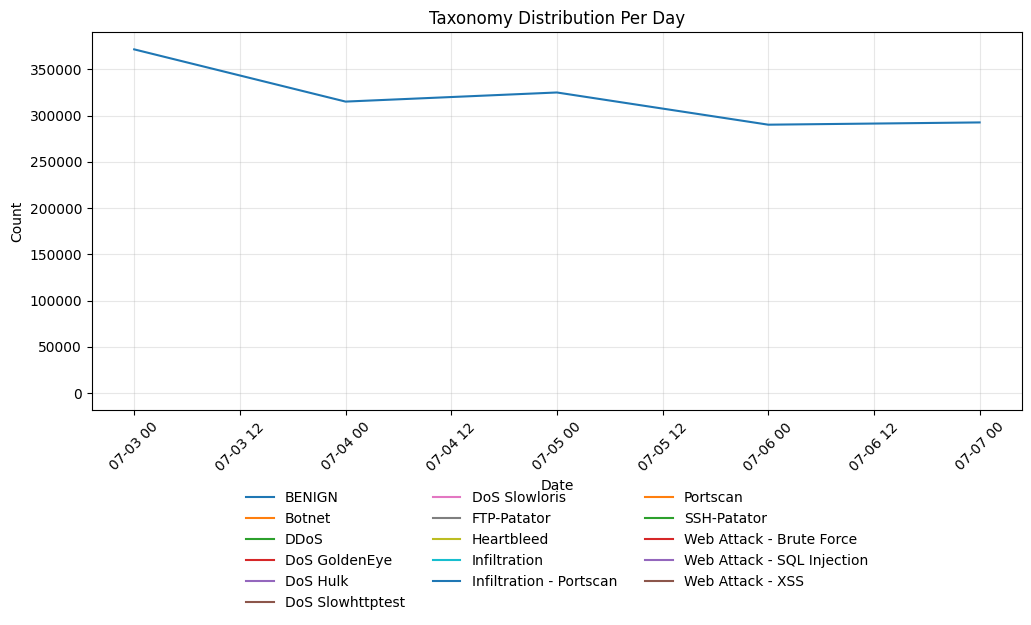

In [15]:
plt.figure(figsize=(12, 6))
for column in taxonomy_daily.columns:
    sns.lineplot(
        x=taxonomy_daily.index,
        y=taxonomy_daily[column],
        label=column
    )

plt.title("Taxonomy Distribution Per Day")
plt.xlabel("Date")
plt.ylabel("Count")
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.legend(
    loc='upper center',
    bbox_to_anchor=(0.5, -0.18),  # center, below the axes
    ncol=3,                       # spread items across columns
    frameon=False
)
plt.subplots_adjust(bottom=0.25)  # make room for the legend
plt.show()

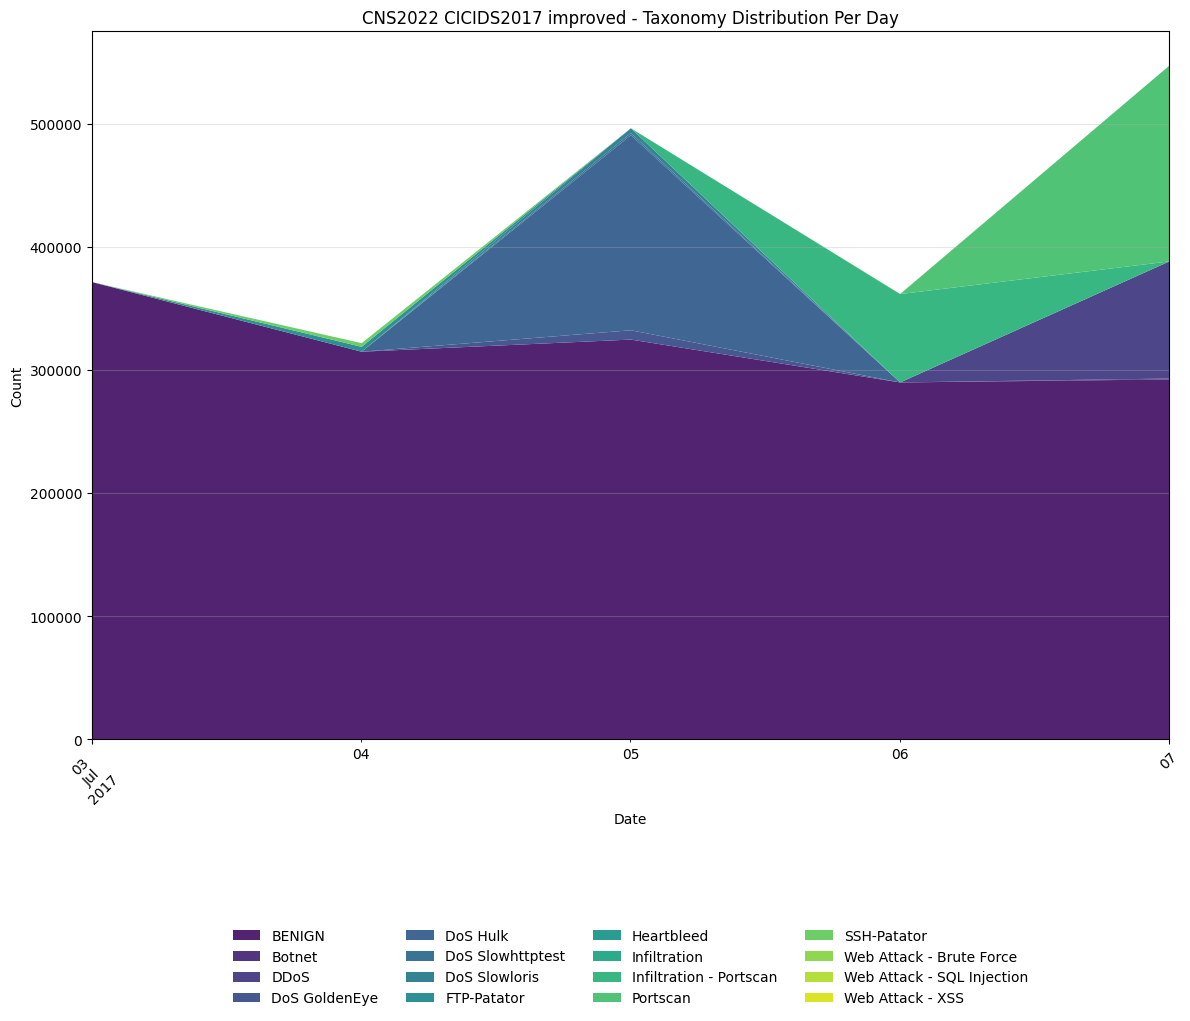

In [16]:
plt.figure(figsize=(12, 10))
tax_cols = list(taxonomy_daily.columns)
tax_palette = sns.color_palette("viridis", n_colors=len(tax_cols))
taxonomy_daily[tax_cols].fillna(0).plot.area(
    stacked=True,
    color=tax_palette,
    linewidth=0.0,
    ax=plt.gca(),
    alpha=0.95
)
plt.title("CNS2022 CICIDS2017 improved - Taxonomy Distribution Per Day")
plt.xlabel("Date")
plt.ylabel("Count")
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.legend(
    loc='upper center',
    bbox_to_anchor=(0.5, -0.25),
    ncol=4,
    frameon=False
)
plt.subplots_adjust(bottom=0.30)
plt.tight_layout()
plt.show()

In [17]:
taxonomy_daily_rel = taxonomy_daily.div(taxonomy_daily.sum(axis=1), axis=0).drop(columns=['BENIGN'])

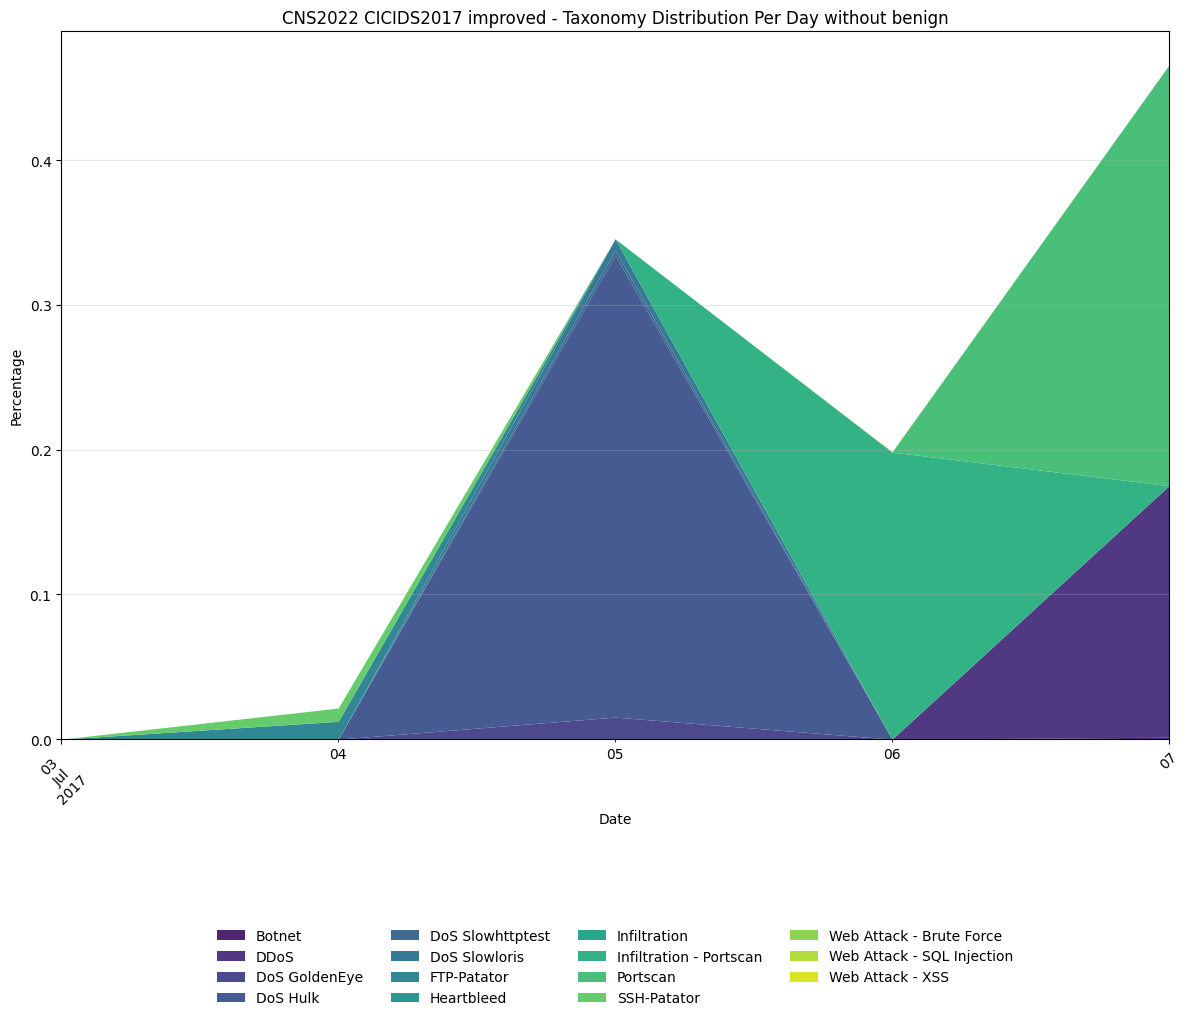

In [18]:
plt.figure(figsize=(12, 10))
tax_cols = list(taxonomy_daily_rel.columns)
tax_palette = sns.color_palette("viridis", n_colors=len(tax_cols))
taxonomy_daily_rel[tax_cols].fillna(0).plot.area(
    stacked=True,
    color=tax_palette,
    linewidth=0.0,
    ax=plt.gca(),
    alpha=0.95
)
plt.title("CNS2022 CICIDS2017 improved - Taxonomy Distribution Per Day without benign")
plt.xlabel("Date")
plt.ylabel("Percentage")
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.legend(
    loc='upper center',
    bbox_to_anchor=(0.5, -0.25),
    ncol=4,
    frameon=False
)
plt.subplots_adjust(bottom=0.30)
plt.tight_layout()
plt.show()

In [19]:
df.write_parquet(data_path / "cns2022_cicids2017_improved.parquet")